# **Gender Pronouns Solution Notebook**<br>

## **1.** OpenSub Dataset Upload

In [1]:
import sys, re, pickle, copy
import pandas as pd
sys.path.append('../modules')
from OpensubHandler import OpenSubDataset

In [2]:
root = "../local_data/opus_opensub/en-pl.txt/"
files = ('OpenSubtitles.en-pl.en', 'OpenSubtitles.en-pl.pl')
ds = OpenSubDataset(root, files, 5000000)
df = ds.clean()
df.head(3)

,eng_text,pol_text,eng_split,pol_split
0,You want to call your daddy?,Chcesz zadzwonić do taty?,"[you, want, to, call, your, daddy, ?]","[chcesz, zadzwonić, do, taty, ?]"
1,"Yeah, I want to tell him I'm okay.","Tak, powiem, że wszystko w porządku.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]"
2,Okay.,Dobrze.,"[okay, .]","[dobrze, .]"


## **2.** Helper Functions

In [3]:
def search(snt, re_pattern):
    return bool(re.search(re_pattern, snt, re.IGNORECASE))

def apply_mask(df, re_pattern, col='pol_text'):
    return df[col].apply(lambda snt: search(snt, re_pattern))

def extract(df_main, df_female, df_male, mask_f, mask_m):
    assert len(df_main) - (~(mask_f | mask_m)).sum() == (mask_f | mask_m).sum()
    
    df_female = pd.concat([df_female, df_main[mask_f]], ignore_index=True)
    df_male = pd.concat([df_male, df_main[mask_m]], ignore_index=True)
    df_main = df_main[~(mask_f | mask_m)].reset_index(drop=True)
    return df_main, df_female, df_male

## **3.** First-Person Sentence Filter

In [4]:
df_text = df[['eng_text', 'pol_text']].copy()

mask_first_person = df_text['eng_text'].str.contains(r"\b(?:i['’](?:m|ve|d|ll)|i|me|my|mine|myself)\b",
                                                     case=False, na=False, regex=True)
print("Num examples: ", mask_first_person.sum(), '\n')

df_first_person = df_text[mask_first_person].reset_index(drop=True)
df_text = df_text[~mask_first_person].reset_index(drop=True)

df_first_person.sample(3)

Num examples:  907395 



,eng_text,pol_text
689623,"Yes, I did.","Tak, wysłuchałem."
877891,I have a flat in Chelsea.,Mam mieszkanko w Chelsea.
398759,I don't want to leave Paris.,Nie chcę opuszczać Paryża.


## **4.** Gender Extraction

In [5]:
df_female = pd.DataFrame(columns=df_first_person.columns)
df_male = pd.DataFrame(columns=df_first_person.columns)

### **GROUP 1**: Past tense endings (łam/łem | łabym/łbym)

In [6]:
edge_cases_f = apply_mask(df_first_person, r'\bdziałam\b|\bdziałam\b|\bzłam\b|\bodłam\b|\brozłam\b|\bs[lł]abym\b')
mask_f = (apply_mask(df_first_person, r'\b\w+łam\b|\b\w+[łl]abym\b') & ~edge_cases_f)

edge_cases_m = apply_mask(
    df_first_person,
    r'\b(materia|cia|z|ko|czo|gard|krzes|mas|źród|god|skrzyd|siod|dzie|szk|do|ty|anio|\
    tytu|artyku|kościo|zespo|szczegó|sto|udzia|wydzia|genera|admira|py|diab|oddzia|kana|kryszta|myd|zapa)łem\b')
mask_m = (apply_mask(df_first_person, r'\b\w+łem\b|\b\w+[łl]bym\b') & ~edge_cases_m)

print(f"Num edge case female: {edge_cases_f.sum()} | Num edge case male: {edge_cases_m.sum()}\n")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")

df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num edge case female: 78 | Num edge case male: 525

Num female: 48807 | Num male: 122013


In [7]:
print(f"{'='*60}\ndf_female sample:\n\n{df_female['pol_text'].sample(3)}\n{'='*60}")
print(f"df_male sample:\n\n{df_male['pol_text'].sample(3)}\n{'='*60}")

df_female sample:

23605    Gdy zeszłam z promu, zrobiłam rundkę po okolicy.
33735                                      Miałam 21 lat.
41729                     Byłam pewna, że jest wcześniej.
Name: pol_text, dtype: object
df_male sample:

57857       Chciałbym przedstawić wam pannę Michele Monet.
12780               Miał pan rację, a ja zawiodłem Eliota.
74544    Wszedłem do pani samochodu tak, jak pani weszł...
Name: pol_text, dtype: object


### **GROUP 2A**: Będę/[..]bym + participle

In [8]:
mask_f = apply_mask(df_first_person, r"\b\w*(bym|bom|będę)\b.+\b\w+ła\b")
mask_m = apply_mask(df_first_person, r"\b\w*(bym|bom|będę)\b.+\b\w+ł\b")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num female: 4246 | Num male: 13153


### **GROUP 2B**: Będę/być/[..]bym + participle

In [9]:
edge_cases_f = apply_mask(df_first_person, r'\b\w*(bym|będę|być)\b\s+\b(sług|gwiazd|glin|inn|sierot|mężczyzn|patriot|maszyn|idiot|\
                                             maszyn|sędzi|tat|sob|osob|azjat|kalek|niemow|głow|porażk|ręk|gaduł|moj|mog|mn|biał|swoj|przynęt)ą\b')

mask_f = apply_mask(df_first_person, r"\b\w*(bym|być|będę)\b.+\b(?!potrzebn|.*pana\b)\w+na\b") | \
         apply_mask(df_first_person, r"\b\w*(bym|być|będę)\b\s+\b\w+ła\b") | \
         apply_mask(df_first_person, r"\b\w*(bym|być|będę)\b\s+\b(?!wa)\w+sza\b") | \
         (apply_mask(df_first_person, r'\b\w*(bym|będę|być)\b\s+\b\w+([ią]c|(os|ie)t|[wkłjn])ą\b') & ~edge_cases_f)

edge_cases_m = apply_mask(df_first_person, r"\b\w*(bym|być|będę)\b.+\bczłowiekiem\b")

mask_m = (apply_mask(df_first_person, r"\b\w*(bym|bom|będę)\b.+\b\w+((n|w|t|ł|sz)y|ym|wym)\b") | \
         apply_mask(df_first_person, r"\b\w*(bym|być|będę)\b.+\b\w*(mężczyzną|kaleką)\b")) & ~edge_cases_m

print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num female: 1168 | Num male: 1404


### **GROUP 3A**: Jestem... Manual Profession Conversion

In [17]:
def get_female_nouns(df_main, nouns_dict, suffixes_dct):
    nouns_pattern = r'|'.join(re.escape(key) for key in nouns_dict.keys())
    mask_nouns = apply_mask(df_main, rf'\bjestem\b.+\b({nouns_pattern})\b')
    print(f"Num examples: {mask_nouns.sum()}")
    female_nouns = df_main[mask_nouns].reset_index(drop=True)
    dct_comb = nouns_dict | suffixes_dct
    pattern_comb = r'|'.join(re.escape(key) for key in dct_comb.keys())
    female_nouns['pol_text'] = female_nouns['pol_text'].apply(lambda snt: re.sub(pattern_comb, 
                                                                                 lambda match: dct_comb[match.group(0).lower()], 
                                                                                 snt, flags=re.IGNORECASE))
    return female_nouns, mask_nouns

- ### **1.** ...arzem --> ...arką (e.g. lekarzem-lekarką | pisarzem-pisarką)

In [18]:
pattern_1 = r'\bjestem\b.+\b(\w+arzem)\b'
nouns_male = df_first_person['pol_text'].str.extract(pattern_1, flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 5].to_dict()
print(nouns_male)

{'lekarzem': 215, 'pisarzem': 36, 'dziennikarzem': 27, 'kucharzem': 19, 'szczęściarzem': 18, 'sekretarzem': 17, 'gospodarzem': 16, 'malarzem': 14, 'weterynarzem': 13, 'komisarzem': 12, 'ochroniarzem': 12, 'marynarzem': 10, 'handlarzem': 9, 'gliniarzem': 8, 'żeglarzem': 7, 'nudziarzem': 6, 'taksówkarzem': 5, 'piosenkarzem': 5}


In [19]:
suffix_conversion = {'ikiem': 'iczką', 'ym': 'ą', 'kim': 'ką', 'ny': 'na', 'twoim': 'twoją'}
nouns_1a = ['lekarzem', 'pisarzem', 'dziennikarzem', 'kucharzem', 'sekretarzem', 'malarzem', 'weterynarzem',
            'ochroniarzem', 'marynarzem', 'handlarzem', 'żeglarzem', 'taksówkarzem', 'piosenkarzem']
nouns_1a = {m_noun: re.sub(r"rzem\b", "rką", m_noun) for m_noun in nouns_1a}

In [20]:
female_nouns_1a, mask_nouns_1a = get_female_nouns(df_first_person, nouns_1a, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_1a sample:\n\n{female_nouns_1a['pol_text'].sample(3)}\n{'='*60}")

Num examples: 391
female_nouns_1a sample:

318              Jestem lekarką, a ona cierpi.
137    Nie jestem lekarką, nie znam się na tą.
50                             Jestem malarką.
Name: pol_text, dtype: object


In [21]:
nouns_1b = {'szczęściarzem': 'szczęściarą', 'gospodarzem': 'gospodynią', 'nudziarzem': 'nudziarą'}
female_nouns_1b, mask_nouns_1b = get_female_nouns(df_first_person, nouns_1b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_1b sample:\n\n{female_nouns_1b['pol_text'].sample(3)}\n{'='*60}")

Num examples: 40
female_nouns_1b sample:

23                       Ja jestem gospodynią.
4                     Tak, jestem szczęściarą.
3     Jestem dobrą gospodynią, pan Stephenson.
Name: pol_text, dtype: object


In [22]:
df_female = pd.concat([df_female, female_nouns_1a, female_nouns_1b], ignore_index=True)
df_male = pd.concat([df_male, df_first_person[mask_nouns_1b | mask_nouns_1a]], ignore_index=True)
df_first_person = df_first_person[~(mask_nouns_1b | mask_nouns_1a)].reset_index(drop=True)

- ### **2.** ...mistrzem --> ...mistrzynią (e.g. [bur]mistrzem - [bur]mistrzynią)

In [23]:
pattern_2 = r'\bjestem\b\s+\b(\w*mistrzem)\b'
nouns_male = df_first_person['pol_text'].str.extract(pattern_2, flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 5].to_dict()
print(nouns_male)

{'mistrzem': 33, 'burmistrzem': 8}


In [24]:
nouns_2 = {'mistrzem': 'mistrzynią', 'burmistrzem': 'burmistrzynią'}
suffix_conversion = {'nym': 'ną', 'kim': 'ką', 'twoim': 'twoją', 'łym': 'łą', 'tym': 'tą', 'sam': 'sama', 'szym': 'szą', 'wym': 'wą'}
female_nouns_2, mask_nouns_2 = get_female_nouns(df_first_person, nouns_2, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_2 sample:\n\n{female_nouns_2['pol_text'].sample(3)}\n{'='*60}")

Num examples: 64
female_nouns_2 sample:

17              Jestem mistrzynią!
57        Jestem waszą mistrzynią.
47    Ja jestem mistrzynią świata.
Name: pol_text, dtype: object


In [25]:
df_female = pd.concat([df_female, female_nouns_2], ignore_index=True)
df_male = pd.concat([df_male, df_first_person[mask_nouns_2]], ignore_index=True)
df_first_person = df_first_person[~(mask_nouns_2)].reset_index(drop=True)

- ### **3.** ...nikiem --> ...niczką/cą (e.g. ochotnikiem - ochotniczką | nieudacznikiem - nieudacznicą)

In [26]:
pattern_3 = r'\bjestem\b.+\b(\w+ikiem)\b'
nouns_male = df_first_person['pol_text'].str.extract(pattern_3, flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = nouns_male[nouns_male >= 4].to_dict()
print(nouns_male)

{'prawnikiem': 65, 'niewolnikiem': 32, 'dłużnikiem': 29, 'wojownikiem': 22, 'anglikiem': 21, 'mechanikiem': 20, 'pracownikiem': 18, 'kierownikiem': 17, 'urzędnikiem': 16, 'wspólnikiem': 15, 'alkoholikiem': 14, 'katolikiem': 12, 'porucznikiem': 11, 'rolnikiem': 11, 'przewodnikiem': 11, 'magikiem': 10, 'nieudacznikiem': 10, 'pułkownikiem': 10, 'pomocnikiem': 9, 'przeciwnikiem': 9, 'komikiem': 9, 'samotnikiem': 8, 'zwolennikiem': 8, 'strażnikiem': 8, 'wysłannikiem': 7, 'grzesznikiem': 7, 'naczelnikiem': 7, 'pośrednikiem': 6, 'zwierzchnikiem': 6, 'chemikiem': 6, 'hydraulikiem': 5, 'robotnikiem': 5, 'rzeźnikiem': 5, 'miłośnikiem': 5, 'technikiem': 4, 'ogrodnikiem': 4, 'królikiem': 4, 'paranoikiem': 4, 'górnikiem': 4}


In [27]:
nouns_3b = ['niewolnikiem', 'anglikiem', 'pracownikiem', 'pomocnikiem', 'grzesznikiem', 'nieudacznikiem', 'robotnikiem']
nouns_3a = [k for k in nouns_male.keys() if k not in nouns_3b+['porucznikiem', 'pułkownikiem', 'królikiem']]

nouns_3b = {k: re.sub(r"nikiem\b|likiem\b", lambda x: {'nikiem': 'nicą', 'likiem': 'ielką'}[x.group(0)], k) for k in nouns_3b}
nouns_3a = {k: re.sub(r"ikiem\b", 'iczką', k) for k in nouns_3a}

In [28]:
suffix_conversion = {'oim': 'oją', 'skim': 'ską', 'okim': 'oką', 'lkim': 'lką', 'akim': 'aką', 'wym': 'wą', 'nikiem': 'niczką',
                     'glikiem': 'gielką', 'olikiem': 'oliczką', 'ym': 'ą', 'czykiem': 'ką', 'óry': 'óra', 'dny': 'dna', 'alny': 'alna'}

female_nouns_3, mask_nouns_3 = get_female_nouns(df_first_person, nouns_3a | nouns_3b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_3 sample:\n\n{female_nouns_3['pol_text'].sample(3)}\n{'='*60}")

Num examples: 450
female_nouns_3 sample:

183                                 Jestem hydrauliczką.
23                  Jestem tylko kierowniczką produkcji.
372    I co mi jest? A skąd mam wiedzieć? Jestem praw...
Name: pol_text, dtype: object


In [29]:
df_female = pd.concat([df_female, female_nouns_3], ignore_index=True)
df_male = pd.concat([df_male, df_first_person[mask_nouns_3]], ignore_index=True)
df_first_person = df_first_person[~(mask_nouns_3)].reset_index(drop=True)

- ### **4.** Final ..em Noun Conversion

In [30]:
pattern_4 = r'\bjestem\b.+\b(\w+em)\b'
nouns_male = df_first_person['pol_text'].str.extract(pattern_4, flags=re.IGNORECASE)[0].str.lower().value_counts()
nouns_male = list(nouns_male[nouns_male >= 5].to_dict())
print(nouns_male)

['człowiekiem', 'jestem', 'przyjacielem', 'ojcem', 'facetem', 'dzieckiem', 'synem', 'tchórzem', 'całkiem', 'szefem', 'żołnierzem', 'wiem', 'głupcem', 'królem', 'bratem', 'policjantem', 'wrażeniem', 'mężem', 'oficerem', 'właścicielem', 'panem', 'chłopcem', 'więźniem', 'złodziejem', 'naukowcem', 'gościem', 'obywatelem', 'ekspertem', 'typem', 'kapitanem', 'agentem', 'członkiem', 'biznesmenem', 'detektywem', 'księdzem', 'żydem', 'fanem', 'aktorem', 'duchem', 'doktorem', 'szpiegiem', 'amerykaninem', 'wrogiem', 'szeryfem', 'dyrektorem', 'dżentelmenem', 'reporterem', 'pilotem', 'rozumiem', 'chirurgiem', 'wariatem', 'nauczycielem', 'razem', 'prezesem', 'klientem', 'kawalerem', 'bogiem', 'chłopakiem', 'bohaterem', 'inżynierem', 'życiem', 'potworem', 'oszustem', 'prawem', 'geniuszem', 'profesorem', 'studentem', 'adwokatem', 'stróżem', 'powrotem', 'kumplem', 'strzelcem', 'księciem', 'dupkiem', 'wielbicielem', 'przejazdem', 'samurajem', 'posłańcem', 'świadkiem', 'partnerem', 'draniem', 'prezydente

In [31]:
nouns_4a = ['aktorem', 'doktorem', 'dyrektorem', 'profesorem', 'amatorem', 'obserwatorem', 'instruktorem', 'inspektorem',
           'autorem', 'reporterem', 'menadżerem', 'trenerem', 'milionerem', 'partnerem', 'farmerem', 'reżyserem',
           'bankierem', 'kelnerem', 'pasażerem', 'uciekinierem', 'kolekcjonerem', 'kurierem', 'kontrolerem', 'gangsterem',
           'frajerem', 'bohaterem', 'klientem', 'ekspertem', 'agentem', 'studentem', 'asystentem', 'pacjentem', 'producentem',
           'komendantem', 'palantem', 'reprezentantem', 'policjantem', 'amerykaninem', 'chrześcijaninem', 'indianinem',
           'wegetarianinem', 'rosjaninem', 'cyganem', 'weteranem', 'barmanem', 'tyranem', 'fanem', 'łajdakiem', 'dziwakiem',
           'maniakiem', 'rybakiem', 'pływakiem', 'wieśniakiem', 'politykiem', 'krytykiem', 'fanatykiem', 'członkiem',
           'nauczycielem', 'wielbicielem', 'przedstawicielem', 'właścicielem', 'złodziejem', 'czarodziejem', 'naukowcem',
           'wędrowcem', 'wariatem', 'piratem', 'filozofem', 'fotografem', 'palaczem', 'włamywaczem', 'psychologiem', 'archeologiem']

nouns_conversion_4a = {'orem': 'orką', 'erem': 'erką', 'entem': 'entką', 'antem': 'antką', 'aninem': 'anką', 'anem': 'anką',
                       'akiem': 'aczką', 'ykiem': 'yczką', 'kiem': 'kinią', 'cielem': 'cielką', 'ejem': 'ejką',
                       'owcem': 'owczynią','atem': 'atką', 'fem': 'fką', 'aczem': 'aczką', 'ogiem': 'ożką', 'rtem': 'rtką'}

nouns_4a = {k: re.sub(rf"{r'|'.join(nouns_conversion_4a)}", lambda x: nouns_conversion_4a[x.group(0)], k) for k in nouns_4a}

In [32]:
nouns_4b = ['przyjacielem', 'szefem', 'więźniem', 'obywatelem', 'kapitanem', 'detektywem', 'żydem', 'prezesem', 'oszustem',
            'geniuszem', 'adwokatem', 'kumplem', 'uczniem', 'jasnowidzem', 'francuzem', 'tancerzem', 'kochankiem', 'opiekunem',
            'niemcem', 'polakiem', 'kuzynem', 'diabłem', 'nowicjuszem', 'brytyjczykiem', 'architektem', 'japończykiem', 'sąsiadem',
            'ministrem', 'irlandczykiem', 'wampirem', 'kanadyjczykiem', 'włochem', 'historykiem', 'wybrańcem', 'listonoszem']

nouns_conversion_4b = {'cielem': 'ciółką', 'telem': 'telką', 'plem': 'pelką', 'fem': 'fową', 'źniem': 'źniarką', 'czniem': 'czennicą',
                        'nem': 'nką', 'wem': 'wką', 'ydem': 'ydówką', 'adem': 'adką', 'sem': 'ską', 'tem': 'tką', 'szem': 'szką', 
                        'ńcem': 'nką', 'dzem': 'dzką', 'uzem': 'uzką', 'rzem': 'rką', 'nkiem': 'nką', 'łem': 'licą', 'akiem': 'ką',
                        'jczykiem': 'jką', 'ńczykiem': 'nką', 'dczykiem': 'dką', 'trem': 'trą', 'irem': 'irką', 'chem': 'szką', 
                        'rykiem': 'ryczką'}

nouns_4b = {k: re.sub(rf"{r'|'.join(nouns_conversion_4b)}", lambda x: nouns_conversion_4b[x.group(0)], k) for k in nouns_4b}

In [33]:
suffix_conversion = {'jakimś': 'jakąś', 'który': 'która', 'ym': 'ą', 'twoim': 'twoją',
                     'zmęczony': 'zmęczona', 'iony': 'iona', 'onny': 'onna', 'orny': 'orna', 'ijny': 'ijna',
                     'jakim': 'jaką', 'niczyim': 'niczyją', 'samotny': 'samotna', 'nikiem': 'niczką',
                     'współpracownikiem': 'współpracownicą', 'zabezpieczony': 'zabezpieczona', 'demokratyczny': 'demokratyczna',
                     'dumny ': 'dumna ', 'dumny,': 'dumna,', 'dumny.': 'dumna.', 'sporządził': 'sporządziła', 
                     'zapłacił': 'zapłaciła', 'pewien': 'pewna', 'drugim': 'drugą', 'głupim': 'głupią', 'skim': 'ską',
                     'bkim': 'bką', 'takim': 'taką', 'lkim': 'lką', 'ckim': 'cką'}

In [35]:
female_nouns_4, mask_nouns_4 = get_female_nouns(df_first_person, nouns_4a | nouns_4b, suffix_conversion)
print(f"{'='*60}\nfemale_nouns_4 sample:\n\n{female_nouns_4['pol_text'].sample(3)}\n{'='*60}")

Num examples: 1963
female_nouns_4 sample:

402                   Nareszcie jestem kapitanką statku.
537              Jestem chwilowo niehonorową członkinią.
802    W przeciwieństwie do ciebie nadal jestem wędro...
Name: pol_text, dtype: object


In [37]:
df_female = pd.concat([df_female, female_nouns_4], ignore_index=True)
df_male = pd.concat([df_male, df_first_person[mask_nouns_4]], ignore_index=True)
df_first_person = df_first_person[~(mask_nouns_4)].reset_index(drop=True)

### **GROUP 3A**: Jestem + immediate adjective

In [66]:
skip_nouns = ['jestem', 'wiem', 'rozumiem', 'powiem', 'całkiem', 'razem', 'czasem', 'przedtem', 'potem', 'przypadkiem', 'pewiem',
              'zerem', 'wyjątkiem', 'numerem', 'powrotem', 'przejazdem', 'wieczorem', 'wpływem', 'względem', 'celem', 'powodem', 'okazem',
              'przykładem', 'byciem', 'czekaniem', 'szukaniem', 'słuchaniem', 'wrażeniem', 'życiem', 'prawem', 'światem', 'sercem', 'głosem',
              'mózgiem', 'narzędziem', 'ciężarem', 'brudem', 'gównem', 'snem', 'stworzeniem', 'autorytetem', 'wrakiem', 'zwierzęciem',
              'psem', 'koniem', 'ogierem', 'szczurem', 'wężem', 'ptakiem', 'ptaszkiem', 'niedźwiedziem', 'człowiekiem', 'dzieckiem', 'tchórzem',
              'gościem', 'duchem', 'wrogiem', 'pilotem', 'chirurgiem', 'bogiem', 'inżynierem', 'potworem', 'stróżem', 'strzelcem', 'posłańcem',
              'świadkiem', 'wilkiem', 'muzykiem', 'aniołem', 'zawodowcem', 'cywilem', 'trupem', 'graczem', 'pijakiem', 'kapusiem', 'kupcem',
              'dzieciakiem', 'czlowiekiem', 'rewolwerowcem', 'roninem', 'demonem', 'bankrutem', 'potomkiem', 'czubkiem']

edge_cases_f = apply_mask(df_first_person, r'\bjestem\b.+\b(sług|gwiazd|glin|inn|sierot|mężczyzn|patriot|maszyn|idiot|\
                                             maszyn|sędzi|tat|sob|osob|azjat|kalek|niemow|głow|porażk|ręk|gaduł)ą\b')

mask_f = apply_mask(df_first_person, r'\bjestem\b\s+\b\w+(([wnktłrmc]|sz|pi|[^y]b)a|([ią]c|(os|ie)t|[wkłjn])ą)\b') & ~edge_cases_f

edge_cases_m = apply_mask(df_first_person, rf"\bjestem\b.+\b({'|'.join(skip_nouns)})\b")
mask_m = apply_mask(df_first_person, r'\bjestem\b\s+\b\w+(y|i|ym|im|iem|em)\b') & ~edge_cases_m

print(f"Num edge case female: {edge_cases_f.sum()} | Num edge case male: {edge_cases_m.sum()}\n")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num edge case female: 557 | Num edge case male: 2031

Num female: 6268 | Num male: 11226


### **GROUP 3B**: Jestem + later adjective

In [110]:
male_nouns = ['dziwolągiem', 'porucznikiem', 'pułkownikiem', 'majorem', 'generałem', 'hetmanem', 'baronem', 'rabinem', 'katem', 'wodzem',
             'gejem', 'lokajem', 'alfonsem', 'świrem', 'dżentelmenem', 'gentlemanem', 'supermanem', 'samurajem', 'rycerzem', 'mnichem',
             'impotentem', 'kawalerem', 'kolesiem', 'czarnuchem', 'ojcem', 'facetem', 'synem', 'żołnierzem', 'bratem', 'mężem', 'panem',
             'oficerem', 'chłopcem', 'królem', 'typem', 'biznesmenem', 'księdzem', 'chłopakiem', 'księciem', 'dupkiem', 'prezydentem',
             'dziadkiem', 'komisarzem', 'gubernatorem', 'gliniarzem', 'zięciem', 'wujkiem', 'starcem', 'durniem', 'szaleńcem',  'rabusiem',
             'funkcjonariuszem', 'senatorem', 'szlachcicem', 'imperatorem', 'pastorem', 'głupcem', 'dezerterem', 'draniem', 'wdowcem', 'głupkiem',
             'kapłanem', 'sukinsynem', 'cykorem', 'sierżantem', 'szeryfem', 'ślepcem', 'szpiegiem']

In [135]:
edge_cases_f = apply_mask(df_first_person, r'\bjestem\b.+\b(\w+[nr]y|\w+ien|gubernatora|generała|sam)\b') | \
               apply_mask(df_first_person, r'\bjestem\b.+\b(sług|gwiazd|glin|inn|sierot|mężczyzn|patriot|maszyn|idiot|\
                                             maszyn|sędzi|tat|sob|osob|azjat|kalek|niemow|głow|porażk|ręk|gaduł|tom|besti)[ąa]\b')

mask_f = apply_mask(df_first_person, r'\bjestem\b\s+\b(.+([wnktłrmc]|sz|pi|[^y]b)a)\b') & ~edge_cases_f

edge_cases_m = apply_mask(df_first_person, rf"\bjestem\b.+\b({'|'.join(skip_nouns)})\b")
mask_m = (apply_mask(df_first_person, r'\bjestem\b.+\b\w+(ien|ny|ym|wy|ty)\b') | \
         apply_mask(df_first_person, rf"\bjestem\b.+\b({'|'.join(male_nouns)})\b")) & ~edge_cases_m 
print(f"Num edge case female: {edge_cases_f.sum()} | Num edge case male: {edge_cases_m.sum()}\n")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num edge case female: 4900 | Num edge case male: 1890

Num female: 2364 | Num male: 4852


### **GROUP 4**: Sam/sama

In [139]:
mask_I = apply_mask(df_first_person, r'\bI\b', col='eng_text')
mask_f = (mask_I & apply_mask(df_first_person, r'\b[Ss]ama\b|\b[Ss]amą\b')) | (mask_I & apply_mask(df_first_person, r'\b[Ss]amej\b.+bie\b'))
mask_m = mask_I & apply_mask(df_first_person, r'\b[Ss]am\b|\b[Ss]amemu\b')
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num female: 1359 | Num male: 2922


### **GROUP 5**: ..nnam/..nienem

In [146]:
mask_f = apply_mask(df_first_person, r"\b\w+nnam\b")
mask_m = apply_mask(df_first_person, r"\b\w+nienem\b")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num female: 1202 | Num male: 2507


### **GROUP 6**: Czuję (się) + adjectives

In [153]:
mask_czuje = apply_mask(df_first_person, r"\bczuj[eę]\b.+\bsi[ęe]\b")
mask_f = mask_czuje & apply_mask(df_first_person, r"\b\w+(na|ka|jsza|wa)\b")
mask_m = mask_czuje & apply_mask(df_first_person, r"\b\w+(ny|ki|jszy|wy|by)\b")
print(f"Num female: {mask_f.sum()} | Num male: {mask_m.sum()}")
df_first_person, df_female, df_male = extract(df_first_person, df_female, df_male, mask_f, mask_m)

Num female: 331 | Num male: 414


In [155]:
df_female.shape, df_male.shape

((68653, 2), (161399, 2))

## **5.** Data Preparation for Training

In [7]:
from BPE_tokenizer import tokenize_eng, tokenize_pol, BPETokenizer, BPEEncoder, get_unique_freqs
import Data, Model_ref, Trainer, Predict
from collections import Counter

### **5.1** Trimming Dataset

In [38]:
def drop_sample(df_main, sample_num):
    sample = df_main.sample(sample_num)
    df_main = df_main.drop(sample.index).reset_index(drop=True)
    return df_main, sample.reset_index(drop=True)

In [39]:
df_female.shape, df_male.shape, df_first_person.shape

((68653, 2), (161399, 2), (680748, 2))

In [40]:
df_first_person, sample_na1 = drop_sample(df_first_person, 32000)
print(df_first_person.shape, sample_na1.shape)
df_first_person, sample_na2 = drop_sample(df_first_person, 32000)
print(df_first_person.shape, sample_na2.shape)

df_female = pd.concat([df_female, sample_na1], ignore_index=True)
df_male = pd.concat([df_male.sample(68653), sample_na2], ignore_index=True)
df_first_person = df_first_person.sample(100653).reset_index(drop=True)
df_other = df_text.sample(450000).reset_index(drop=True)

(648748, 2) (32000, 2)
(616748, 2) (32000, 2)


### **5.2** Training BPE Tokenzier

In [41]:
df_female['eng_split'] = df_female['eng_text'].apply(tokenize_eng)
df_female['pol_split'] = df_female['pol_text'].apply(tokenize_pol)

df_male['eng_split'] = df_male['eng_text'].apply(tokenize_eng)
df_male['pol_split'] = df_male['pol_text'].apply(tokenize_pol)

df_first_person['eng_split'] = df_first_person['eng_text'].apply(tokenize_eng)
df_first_person['pol_split'] = df_first_person['pol_text'].apply(tokenize_pol)

df_other['eng_split'] = df_other['eng_text'].apply(tokenize_eng)
df_other['pol_split'] = df_other['pol_text'].apply(tokenize_pol)

In [30]:
vocab_chars_eng1, pair_vocab_eng1, vocab_chars_pol1, pair_vocab_pol1 = get_unique_freqs(
    pd.concat([df_female, df_male, df_first_person], ignore_index=True), 'eng_split', 'pol_split')

Src vocab size: 39376 | Tgt vocab size: 99352


In [32]:
tokenizer_eng1 = BPETokenizer(vocab_chars_eng1, pair_vocab_eng1, 12000, 600)
tokenizer_pol1 = BPETokenizer(vocab_chars_pol1, pair_vocab_pol1, 24000, 600, True, ['<bos>', '<self_na>', '<self_m>', '<self_f>'])

In [35]:
tokenizer_eng1.train_bpe()
tokenizer_pol1.train_bpe()

  0%|          | 0/11945 [00:00<?, ?it/s]

  0%|          | 0/23932 [00:00<?, ?it/s]

In [29]:
vocab_chars_eng2, pair_vocab_eng2, vocab_chars_pol2, pair_vocab_pol2 = get_unique_freqs(
    pd.concat([df_female, df_male, df_first_person, df_other], ignore_index=True), 'eng_split', 'pol_split')

Src vocab size: 65120 | Tgt vocab size: 170530


In [43]:
tokenizer_eng2 = BPETokenizer(vocab_chars_eng2, pair_vocab_eng2, 24000, 600)
tokenizer_pol2 = BPETokenizer(vocab_chars_pol2, pair_vocab_pol2, 48000, 600, True, ['<bos>', '<self_na>', '<self_m>', '<self_f>'])

In [44]:
tokenizer_eng2.train_bpe()
tokenizer_pol2.train_bpe()

  0%|          | 0/23945 [00:00<?, ?it/s]

  0%|          | 0/47932 [00:00<?, ?it/s]

### **5.3** Encoding The Data

In [37]:
encoder_pol1 = BPEEncoder(tokenizer_pol1.vocab, tokenizer_pol1.vocab_chrs, 68, True)
encoder_eng1 = BPEEncoder(tokenizer_eng1.vocab, tokenizer_eng1.vocab_chrs, 55, False)

In [47]:
encoder_pol2 = BPEEncoder(tokenizer_pol2.vocab, tokenizer_pol2.vocab_chrs, 68, True)
encoder_eng2 = BPEEncoder(tokenizer_eng2.vocab, tokenizer_eng2.vocab_chrs, 55, False)

In [42]:
df_female['eng_ids'] = df_female['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_female['pol_ids'] = df_female['pol_split'].apply(lambda tab: [7, 4] + encoder_pol1.encode_snt(tab) + [2])

df_male['eng_ids'] = df_male['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_male['pol_ids'] = df_male['pol_split'].apply(lambda tab: [6, 4] + encoder_pol1.encode_snt(tab) + [2])

df_first_person['eng_ids'] = df_first_person['eng_split'].apply(lambda tab: encoder_eng1.encode_snt(tab) + [2])
df_first_person['pol_ids'] = df_first_person['pol_split'].apply(lambda tab: [5, 4] + encoder_pol1.encode_snt(tab) + [2])

In [43]:
df_female2 = copy.deepcopy(df_female)
df_male2 = copy.deepcopy(df_male)
df_first_person2 = copy.deepcopy(df_first_person)

In [56]:
df_female2['eng_ids'] = df_female2['eng_split'].apply(lambda tab: encoder_eng2.encode_snt(tab) + [2])
df_female2['pol_ids'] = df_female2['pol_split'].apply(lambda tab: [7, 4] + encoder_pol2.encode_snt(tab) + [2])

df_male2['eng_ids'] = df_male2['eng_split'].apply(lambda tab: encoder_eng2.encode_snt(tab) + [2])
df_male2['pol_ids'] = df_male2['pol_split'].apply(lambda tab: [6, 4] + encoder_pol2.encode_snt(tab) + [2])

df_first_person2['eng_ids'] = df_first_person2['eng_split'].apply(lambda tab: encoder_eng2.encode_snt(tab) + [2])
df_first_person2['pol_ids'] = df_first_person2['pol_split'].apply(lambda tab: [5, 4] + encoder_pol2.encode_snt(tab) + [2])

df_other['eng_ids'] = df_other['eng_split'].apply(lambda tab: encoder_eng2.encode_snt(tab) + [2])
df_other['pol_ids'] = df_other['pol_split'].apply(lambda tab: [5, 4] + encoder_pol2.encode_snt(tab) + [2])

### **5.4** Sample Extraction

In [57]:
sample_f1, sample_m1, sample_na1 = df_female.sample(653), df_male.sample(653), df_first_person.sample(653)
df_female, df_male, df_first_person = df_female.drop(sample_f1.index), df_male.drop(sample_m1.index), df_first_person.drop(sample_na1.index)

In [58]:
sample_f2, sample_m2, sample_na2 = df_female2.sample(653), df_male2.sample(653), df_first_person2.sample(653)
df_female2, df_male2, df_first_person2 = df_female2.drop(sample_f2.index), df_male2.drop(sample_m2.index), df_first_person2.drop(sample_na2.index)

In [62]:
df_female.shape, df_male.shape, df_first_person.shape

((100000, 6), (100000, 6), (100000, 6))

In [61]:
df_female2.shape, df_male2.shape, df_first_person2.shape, df_other.shape

((100000, 6), (100000, 6), (100000, 6), (450000, 6))

### **5.5** Combining Data

In [64]:
df_data1 = pd.concat([df_female[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_male[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']], 
                      df_first_person[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']]], ignore_index=True)

In [87]:
mask_eng = df_data1['eng_ids'].str.len() <= 35
mask_pol = df_data1['pol_ids'].str.len() <= 35

In [91]:
df_data1 = df_data1[mask_eng & mask_pol].reset_index(drop=True)

In [65]:
df_data2 = pd.concat([df_female2[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_male2[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']], 
                      df_first_person2[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']],
                      df_other[['eng_split', 'pol_split', 'eng_ids', 'pol_ids']]], ignore_index=True)

In [93]:
mask_eng = df_data2['eng_ids'].str.len() <= 35
mask_pol = df_data2['pol_ids'].str.len() <= 35

In [95]:
df_data2 = df_data2[mask_eng & mask_pol].reset_index(drop=True)

In [97]:
df_train1, df_val1 = Data.shuffle_split(df_data1, 0.9)
print(f"{df_train1.shape}, {df_val1.shape}")
train_data1 = Data.EngPolDataset(df_train1, 'eng_ids', 'pol_ids')
val_data1 = Data.EngPolDataset(df_val1, 'eng_ids', 'pol_ids')

(269991, 4), (30000, 4)


In [99]:
df_train2, df_val2 = Data.shuffle_split(df_data2, 0.95)
print(f"{df_train2.shape}, {df_val2.shape}")
train_data2 = Data.EngPolDataset(df_train2, 'eng_ids', 'pol_ids')
val_data2 = Data.EngPolDataset(df_val2, 'eng_ids', 'pol_ids')

(712492, 4), (37500, 4)


## **6.** Training Models

- ### **Solution v2:** First-Person Opensub Model

In [104]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8

encoder_1 = Model_ref.TransformerEncoder(12000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 37)
decoder_1 = Model_ref.TransformerDecoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 37)
model_1 = Model_ref.Seq2Seq(encoder=encoder_1, decoder=decoder_1, lr=0.0001, pad_id=0, n_ref=1, device='cuda')
trainer_1 = Trainer.TrainerModule(batch_size=64)
trainer_1.plotter_init("Ver.2 First-Person Opensub Model")

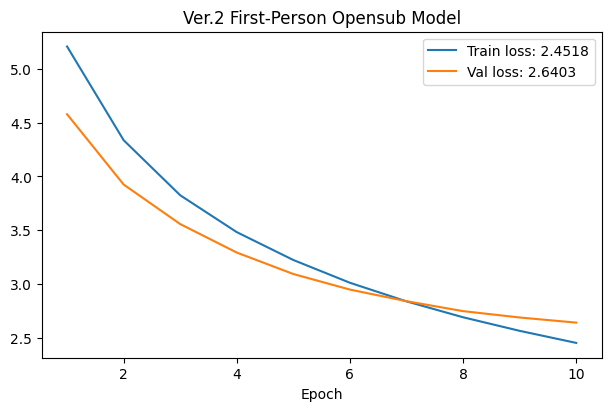

In [105]:
trainer_1.fit(model_1, train_data1, val_data1, 10, '../checkpoints/first_sentence_only')

- ### **Solution v2:** Various Opensub Model

In [106]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8

encoder_2 = Model_ref.TransformerEncoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 37)
decoder_2 = Model_ref.TransformerDecoder(48000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, 37)
model_2 = Model_ref.Seq2Seq(encoder=encoder_2, decoder=decoder_2, lr=0.0001, pad_id=0, n_ref=1, device='cuda')
trainer_2 = Trainer.TrainerModule(batch_size=64)
trainer_2.plotter_init("Ver.2 Various OpenSub Model")

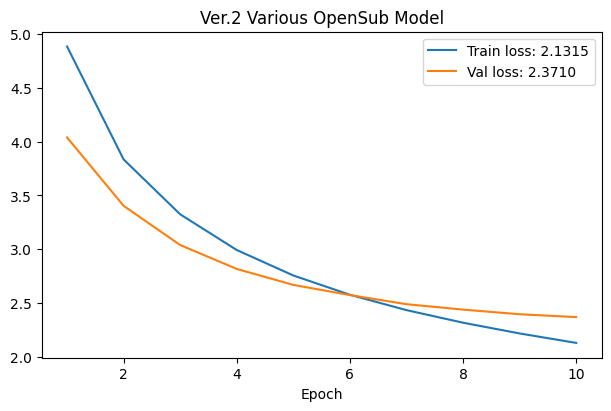

In [107]:
trainer_2.fit(model_2, train_data2, val_data2, 10, '../checkpoints/gender_opensub_various')